## Import Requied Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import adi

#  <font color="red">Source Coding</font>



- ASCII Source Coding

ASCII source coding is a simple way of representing characters (letters, numbers, symbols) in digital communication using a fixed number of bits. ASCII stands for American Standard Code for Information Interchange. In this system, each character is assigned a unique 7-bit binary code (sometimes extended to 8 bits). For example, the letter 'A' is represented as 1000001 in binary, and the digit '1' is represented as 0110001

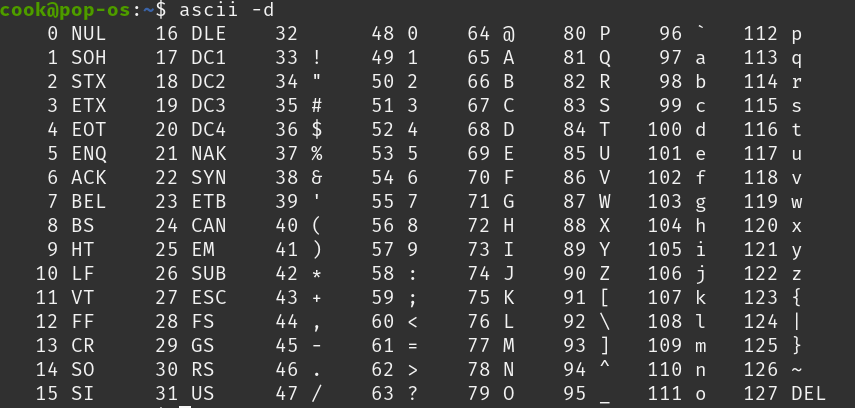

## Task 1:Text to ASCII Equivallent Binary Digits

- Convert each character of the given text message string into its ASCII decimal number.

- Convert each ASCII decimal number into its 7-bit binary representation.

- Concatenate all 7-bit binary codes to form a single binary string.

- Convert the binary string into an array (list) of binary digits (0s and 1s).

In [ ]:
text_message = 'Digital Communication and Coding Theory'

# Write your code here

message_bits =

## Task 2: Decode Binary Digits to Text

- Divide the binary array into chunks of 7 bits each.

- Convert each 7-bit chunk into its corresponding ASCII decimal number.

- Map each ASCII number to its equivalent text character.

- Join all characters together to form the decoded text message.

In [ ]:
# Write your code here

decoded_text_message =

# <font color="red">Modulation </font>

-  BPSK Modulation

When we do BPSK modulation, we first take the message bits (0s and 1s) and map them into symbols before putting them on the wave.

A bit 0 is usually mapped to the symbol +1. A bit 1 is usually mapped to the symbol –1.

So the message bit stream like: `[0,1,0,0,1]`
becomes the BPSK symbol stream: `[+1,−1,+1,+1,−1]`

These symbols are then used to change the phase of the carrier wave:

+1 means transmit the carrier as it is (0° phase). –1 means transmit the carrier flipped (180° phase).

# Task 3: Convert Message Bits to BPSK Modulated Symbols

- Take the message bits (a sequence of 0s and 1s).

- Map each bit to a BPSK symbol: Bit 0 → Symbol +1. Bit 1 → Symbol –1

- Form a sequence of BPSK symbols corresponding to the message bit stream.

In [ ]:
message_bits = # assign generated message bits

# Write your code here

bpsk_symbols  =

#  <font color="red">Pulse Shaping</font>

- Square Pulse Shaping

When we generate modulated symbols in digital communication (for example, BPSK symbols like +1 and -1), they first exist as discrete values in time. If we transmit them directly, we would usually hold each symbol value constant over its symbol duration, which results in a square pulse shape. This is called square pulse shaping or rectangular pulse shaping.

In this case, every symbol is multiplied by a rectangular pulse of fixed width (equal to the symbol duration). So, a sequence of modulated symbols like +1, -1, +1 will look like a train of square pulses, where each pulse’s height corresponds to the symbol value.

- Square Pulse

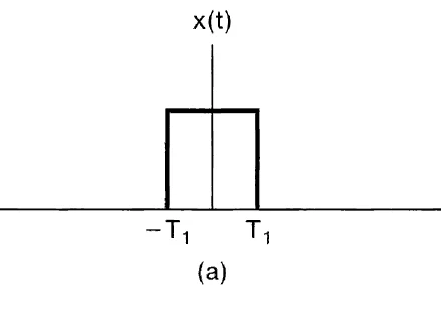

- A square pulse of period $p$ has an amplitude of $1$ for the entire duration $p$.

- Represented as an array, it consists of $p$ consecutive values of  $1$


### Samples per Symbol (sps)

- In pulse shaping, each BPSK symbol (`+1` or `−1`) is expanded into multiple samples.

- If the samples per symbol (`sps`) is `8`, then each BPSK symbol is represented by a sequence of `8` identical samples.

- For example, a symbol
`+1` becomes
`[1,1,1,1,1,1,1,1]`, and a symbol
`−1` becomes
`[−1,−1,−1,−1,−1,−1,−1,−1]`.

In [ ]:
# sps --> Samples Per Symbol
sps = 8

# Square pulse can be generated as below.
square_pulse = np.ones(sps)

## Task 4: Do Pulse Shaping

- Convert BPSK symbols into zero padded sequence, where you append `sps - 1` zeros after each BPSK symbols and concatenate

- Examples: If `sps = 4`, BPSK symbols `[+1, -1, +1, +1, -1]` is convert zero padded sequence as `[1, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0 ]`

- If `sps = 8` zero padded sequence look like below image.

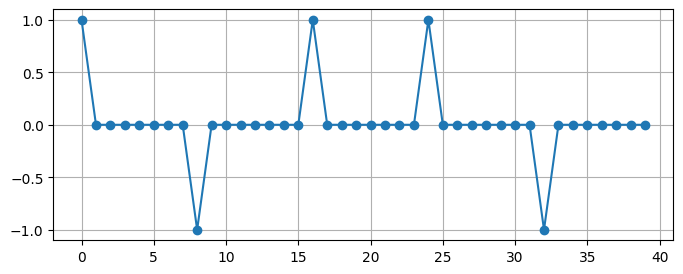

In [ ]:
bpsk_symbols = # Use BPSK symbols you generated previously

# TO DO: Write code to generate zero padded sequence

zero_padded_sequence =

# TO DO: Plot the zero padded sequence


 - To generate a pulse shaped signal, do convolution of zero padded sequence with `square_pulse`
 - Use convolution `mode = 'full'` and remove last `'sps - 1` samples from convolution output as it is result of convolution with zeros

-  Your pulse shaped signal look like below image.

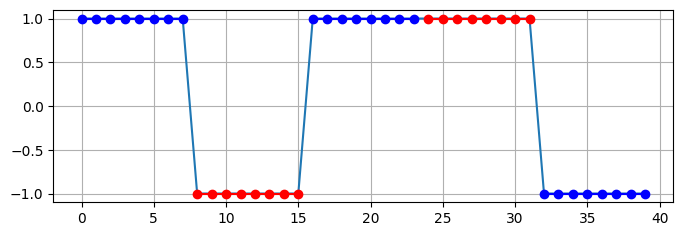

In [ ]:
# TO DO: Convolve the zero padded sequence with `square_pulse`,
# 'mode = full` and remove last 'sps - 1'` symbols from convolution output

sps = 8
square_pulse = np.ones(sps)

# write youse code here

pulse_shaped_signal =

# TO DO: Plot pulse shaped signal


# <font color="red"> Downsampling </font>
Downsampling in a discrete signal means reducing the number of samples by keeping only every
$M^{\rm th}$ sample from the original sequence. If the original signal is
$x[k]$, the downsampled signal is $y[k]=x[Mk]$, where
$M$ is the downsampling factor.



- To get back original modulated symbols, we need to sample from the pulse shaped signal

- downsampling_factor (M) = `sps`
- Collect every `sps`-th sample from the pulse shaped signal

- Compare downsampled_signal with original BPSK modulated symbols

In [ ]:
pulse_shaped_signal =  # assign generated pulse shaped signal

downsamplig_factor = sps

# Write your code here

downsampled_signal =

# <font color="red"> Barker Code </font>

Refer: https://en.wikipedia.org/wiki/Barker_code

A Barker code is a special sequence of binary values (either +1/–1 or 1/0) used in communication systems for synchronization and detection. The key property of a Barker code is that its autocorrelation is very low except at zero shift, which means the sequence matches strongly only with itself and not with shifted versions. This makes it excellent for identifying the start of a signal (preamble) in noisy environments, such as in radar and wireless communication.

- Perform autocorrelation operation with 2 identical barker codes and plot correlation output. Use `mode = 'full'`

- 13 length barker code `[1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]`

In [ ]:
barker_code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])

# TO DO: Perform autocorrelation

# TO DO: Plot Correlation result

## Where is the Transmitted Signal in the Received Signal?

- In the received signal, there is usually a prefix (extra signal part) followed by the actual transmitted (original) signal. However, the receiver does not directly know where the original signal starts. This creates uncertainty, because without knowing the exact starting point, proper recovary and decoding of the message is not possible.

- Observe in the below images.




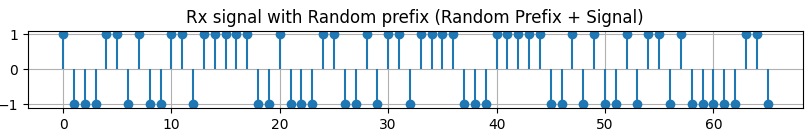

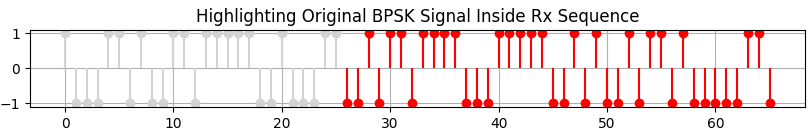

## <font color="red"> Frame Synchronization using Barker Code </font>

- Above problem is solved by frame synchronization. It helps the receiver correctly find the beginning of the transmitted signal. One common way to achieve this is by using Barker codes, which are special binary sequences with excellent autocorrelation properties

- Choose a Barker sequence (e.g., length 13 barker code `[1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]`)

- Append the Barker code at the beginning of the transmitted signal (acts as a known preamble).

- Transmited the signal is Barker code + original BPSK signal.

- Received signal is some prefix signal followd by transmitted signal.

- At the receiver: Cross-correlate the received signal with the known Barker code.

- The point where correlation is maximum indicates the starting position of the original data.

- Collect received data from this position to achieve correct frame synchronization and to get back original BPSK signal.

In [ ]:
test_orginal_BPSK_signal = np.array([-1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1,  1, -1, -1,  1])

barker_code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])

text_TX_signal = np.concatenate((barker_code, test_orginal_BPSK_signal))

print('TX signal', text_TX_signal)

n = np.random.randint(5, 15)
pre_sequence = np.random.choice([-1, 1], size=n)

text_TX_signal = np.concatenate((pre_sequence, text_TX_signal))

print('\nRX signal', text_TX_signal)

TX signal [ 1  1  1  1  1 -1 -1  1  1 -1  1 -1  1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1
  1 -1 -1  1]

RX signal [ 1  1  1  1  1 -1 -1  1  1 -1 -1  1  1  1  1  1  1  1 -1 -1  1  1 -1  1
 -1  1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1  1 -1 -1  1]


## Task 5: Find the starting index of transmitted signal

In [ ]:

# TO DO: cross-correlate the RX signal with barker code, use mode = 'full'
correlation_output =

# TO DO: Plot the correlation output

# TO DO: identify the index where where the correlatin output is maximum.
# start_index = argmax( correlation output) + 1

start_index =

# Verify ------ start_index = lenght of pre sequence (n) + length of barker code (13)

# Collect the data z points from the star_index from RX signal, where z is length of original signal

collected_samples =

# Verify ----- collected samples = original BPSK signal


# <font color="black"> Transmit and Receive in 2 different SDRs </font>

# <font color="red"> TRANSMITTER </font>

## <font color="red"> If you are transmitting perform the below tasks


## <font color="red"> Task 1: Configure Transmitting SDR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import adi

# From PySDR
sample_rate = 1e6 # Hz
center_freq = _____e6 # Hz  (Select appropriate carrier frequency for transmission, in range 400 MHz - 1300MHz)
num_samps = 1000000 # number of samples per call to rx()

sdr = adi.Pluto("ip:192.168.2.1")
sdr.sample_rate = int(sample_rate)

#################################################
# Config Tx
sdr.tx_rf_bandwidth = int(sample_rate) # filter cutoff, just set it to the same as sample rate
sdr.tx_lo = int(center_freq)
sdr.tx_hardwaregain_chan0 = -10 # Increase to increase tx power, valid range is -90 to 0 dB

## <font color="red"> Task 2: Do Source Coding



In [ ]:
text_message = 'Digital Communication and Coding Theory'

# Write your code here

message_bits =

## <font color="red"> Task 3: Do BPSK Modulation

In [ ]:
# Write your code here

bpsk_symbols  =

## <font color="red"> Task 4: Append Barker Code </font>

- Append 13-length barker code before (prefix) the bpsk_symbols, use concatenation.

- barker_code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])

In [ ]:
barker_code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])

# Write your code here

barker_appended_bpsk =

## <font color="red"> Task 5: Do Pulse Shaping

In [ ]:
barker_appended_bpsk =       #assign your generated sequence (use this sequence further, i.e., for zero padding)

# TO DO: Write code to generate zero padded sequence

zero_padded_sequence =


### Plot zero padded sequence

In [ ]:
# Write your code here



### Pulse shaping - Convolution

In [ ]:
# TO DO: Convolve the zero padded sequence with `square_pulse`,
# 'mode = full` and remove last 'sps - 1'` symbols from convolution output

sps = 16
square_pulse = np.ones(sps)

# write youse code here

pulse_shaped_signal =


### Plot pulse shaped signal

In [ ]:
# write your code here



### Plot scatter-plot of pulse shaped signal

In [ ]:
#write your code here



## <font color="red"> Task 6: Increase amplitude of transmitting signal suitable for SDR </font>

- Increase the pulse shaped signal amplitude, multiply the signal with $2^{14}$.

In [ ]:
signal = pulse_shaped_signal

tx_signal =   # Write your code here


## <font color="red"> Task 7: Transmit the signal using SDR

In [ ]:
sdr.tx_cyclic_buffer = True  # Enable cyclic buffers

sdr.tx(tx_signal)  # Start transmitting

print('Transmission Started')

# <font color="blue"> RECEIVER </font>



## <font color="blue"> If you are receiving perform the below tasks

## <font color="blue"> Task 1: Receive signal using SDR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import adi

# From PySDR
sample_rate = 1e6 # Hz
center_freq = ______e6 # Hz  (Select same carrier frequency used
                            # for transmission to receive the signal)
num_samps = 1000000 # number of samples per call to rx()

sdr2 = adi.Pluto("ip:192.168.2.1")
sdr2.sample_rate = int(sample_rate)

sdr2.rx_lo = int(center_freq)
sdr2.rx_rf_bandwidth = int(sample_rate)
sdr2.rx_buffer_size = num_samps

# sdr2.gain_control_mode_chan0 = 'manual'
# sdr2.rx_hardwaregain_chan0 = 70 # dB, increase to increase the receive gain, but be careful not to saturate the ADC

sdr2.gain_control_mode_chan0 = 'slow_attack'

# Receive samples
rx_samples = sdr2.rx()
print('received samples \n', rx_samples)

### Plot the received signal

In [ ]:
# Write your code here



### Plot scatter-plot of received signal

In [ ]:
# write your code here



## <font color="blue"> Task 2: Normalize the Received signal </font>

- Normalize the received signal in range -1 to +1

- Compute magnitudes of the received signal, magnitude  = absolute of received signal

- Normalized signal = Received signal / magnitudes

In [ ]:
# Write your code here

magnitudes =

norm_rx_signal =


### Plot normalized signal

In [ ]:
# Write your code




### Plot scatter-plot of normalized signal

In [ ]:
# Write your code here




## <font color="blue"> Task 3: Coarse Frequency Synchronization </font>

- Refer: https://pysdr.org/content/sync.html - section - Coarse Frequency Synchronization

- Even though we tell the transmitter and receiver to operate on the same center frequency, there is going to be a slight frequency offset between the two due to either imperfections in hardware (e.g., the oscillator) or a Doppler shift from movement. This frequency offset will be tiny relative to the carrier frequency, but even a small offset can throw off a digital signal

- Frequency synchronization is usually broken down into coarse sync and fine sync, where coarse corrects large offsets on the order of kHz or more, while the fine sync corrects whatever is left.

- In order to perform coarse frequency offset estimation (if we can estimate the offset frequency, then we can undo it), is to take the square of our signal.

- $r^2(t) = s^2(t) e^{j4 \pi f_0 t}$

- A simple method for figuring out
 is to take the FFT of the signal after we square it N times and seeing where the spike occurs

 - Actually correcting this frequency offset is multiplying by a complex exponential, except with a negative sign since we want to remove the offset.

In [ ]:
squared_signal = norm_rx_signal**2. # run this code

### Plot the psd of the squared_signal

In [ ]:
### Write tour code here



### Find the frequency where maximum psd value occurs


In [ ]:
# run this code

fs = sample_rate

f = np.linspace(-fs/2.0, fs/2.0, len(psd))

max_freq = f[np.argmax(psd)]

### Coarse correction

- $r^2(t)e^{-j2\pi\frac{(maxfreq)}{2} t}$


In [ ]:
# run this code

Ts = 1/fs # calc sample period

t = np.arange(0, Ts*len(norm_rx_signal), Ts) # create time vector

coarse_corrected = norm_rx_signal * np.exp(-1j*2*np.pi*max_freq*t/2.0)

### Plot the coarse corrected signal

In [ ]:
### Write your code here



### Plot scatter-plot of coarse corrected signal

In [ ]:
# Write your code here



## <font color="blue"> Task 4:  Do Downsampling </font>

- Downsample the coarse_corrected signal

-  Downsampling factor = sps = 16

In [ ]:
sps = 16 # downsampling factor
downsamplig_factor = sps
# Write your code here

down_sampled_signal =

### Plot the downsampled signal

In [ ]:
# write your code here



### Plot scatter-plot of downsampled signal

In [ ]:
# write your code here



## <font color="blue"> Task 5: Fine frequency Synchronization </font>

- Refer:  https://pysdr.org/content/sync.html -- section - Fine Frequency Synchronization

### Use the following code

In [ ]:
# run this code

samples = down_sampled_signal

# Parameters
N = len(samples)
phase = 0
freq = 0
alpha = 0.132
beta = 0.00932

# Costas Loop
fine_correct = np.zeros(N, dtype=np.complex64)
freq_log = []
for i in range(N):
    fine_correct[i] = samples[i] * np.exp(-1j*phase)
    error = np.real(fine_correct[i]) * np.imag(fine_correct[i])
    freq += (beta * error)
    freq_log.append(freq * fs / (2*np.pi))
    phase += freq + (alpha * error)
    while phase >= 2*np.pi:
        phase -= 2*np.pi
    while phase < 0:
        phase += 2*np.pi

#############################
fine_corrected = fine_correct
##############################


# Plot correction status over number of samples
plt.figure(figsize=(5, 3))
plt.plot(freq_log,'.-')
plt.show()

### Plot the fine corrected signal

In [ ]:
# write your code here



### Plot scatter-plot of fine corrected signal

In [ ]:
# Write your code here



## <font color="blue"> Task 6: Frame Synchronization

### Compute cross-correlation output

-  Cross correlate the fine_corrected with barker code, use mode = 'full'

In [ ]:
correlation_output =  # Write your code here



### Plot the correlation output

In [ ]:
# write your code here



### Find the starting index of original BPSK

- starting index = arg max of ( absolute value of correlation output ) + 1

In [ ]:
start_index = # Write your code here



### Rotate the fine corrected signal if maximum (peak) of correlation output is negative

- Why ? think.

- Use the following code.

In [ ]:
# run this code
peak = np.real(correlation_output)[start_index-1]
if peak < 0:
    fine_correct = -1*fine_correct


### Collect samples starting from start_index

 -  Use n_bits (numbers of samples to collect) = 52

 - 52 = number of message bits

 - Receiver cannot know this, unless TX and RX agreed for fixed number of bits transmission and reception each time, this fixed number is called payload size.

 - You will learn more about this later.

In [ ]:
n_bits =   # Know by your adjacent transmitting partner

fr_sync_op = fine_correct[start_index:start_index+n_bits]

### Plot scatter-plot frame syanchronization output

In [ ]:
# scatter plot of fr_sync_op

# Write your code here



## <font color="blue"> Task 7: Demodulation </font>

- Do the reverse of BPSK modulation

- Map to bit 0 if symbol is -1, map to bit 1 if symbol is +1.


In [ ]:
# Demodulate the fr_sync_op

# Wtite your code here

recovered_bits =

## <font color="blue"> Task 8: Decode Recovered to Text </font>

- Divide the recovered_bits array into chunks of 7 bits each.

- Convert each 7-bit chunk into its corresponding ASCII decimal number.

- Map each ASCII number to its equivalent text character.

- Join all characters together to form the decoded text message.

- Compare the decoded message with transmitte message (know this by your adjacent transmitter.)

In [ ]:
# write your code here

final_decoded_message = 


###